# Social Media Text Preprocessing

This notebook cleans and preprocesses Meta and Bluesky posts for downstream NLP analysis.

- Load raw Meta and Bluesky data  
- Detect language and keep English posts  
- Clean text (lowercase, remove URLs, mentions, emojis, boilerplate)  
- Remove short posts (<10 characters)  
- Summarize dataset size before and after cleaning  


# read the file and check the language types

## meta full dataset

In [ ]:
import pandas as pd
file = 'your_file_path_here'

In [ ]:
meta = pd.read_csv(file + 'meta_data.csv')
meta.head(2)

,ad_archive_id,page_id,page_name,ad_creation_time,ad_delivery_start_time,ad_delivery_stop_time,byline,ad_creative_bodies,ad_creative_link_titles,ad_creative_link_captions,ad_creative_link_descriptions,impressions,spend,currency,demographic_distribution,delivery_by_region,publisher_platforms,estimated_audience_size,languages
0,1113427194265921,292649794717694,The Bulwark,2025-09-28,2025-09-28,2025-09-29,Bulwark Media,Yesterday we moved on to the dysgenic portion ...,"Autism, MAHA, and the Face of God",thebulwark.com,"One part junk science, two parts incompetent g...","lower_bound: 0, upper_bound: 999","lower_bound: 0, upper_bound: 99",USD,"{""age"":""18-24"",""gender"":""female"",""__umapi_quer...","{""region"":""Alabama"",""__umapi_query_id"":""8qri3i...","facebook,instagram",lower_bound: 1000001,en
1,3091537204359777,11111618026,Union of Concerned Scientists,2025-09-25,2025-09-25,NaN,"UNION OF CONCERNED SCIENTISTS, INC.",⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...,"DOUBLE YOUR IMPACT,DOUBLE YOUR IMPACT","ucs.org/donate,ucs.org/donate",NaN,"lower_bound: 9000, upper_bound: 9999","lower_bound: 500, upper_bound: 599",USD,"{""age"":""18-24"",""gender"":""female"",""__umapi_quer...","{""region"":""Alabama"",""__umapi_query_id"":""td34wn...","facebook,instagram",lower_bound: 1000001,en


In [84]:
meta['languages'].unique()

array(['en', nan, 'en,uk,da,eo,ur', 'es', 'ar', 'pt', 'hi', 'es,en', 'ja',
       'fr', 'ht', 'it', 'zh', 'id', 'vi', 'he',
       'en,sq,az,be,ar,bs,eu,hy', 'en,hi,ml,ta,be,ka,hy,he,ne',
       'ml,en,zh,ko,ja,th,ta', 'ko', 'ru', 'tr', 'en,es',
       'en,cs,is,el,da', 'km'], dtype=object)

In [85]:
# meta['language'].value_counts()              # count
meta['languages'].value_counts(normalize=True) # percentage

,proportion
languages,
en,0.993193
es,0.003464
pt,0.000608
zh,0.000425
ar,0.000365
"es,en",0.000243
fr,0.000182
it,0.000182
vi,0.000182


## bluesky full dataset

In [86]:
bluesky = pd.read_csv(file + 'bluesky_data.csv')
bluesky.head(2)

,author,author_did,indexed_at,text,uri,cid
0,lynnc1955.bsky.social,did:plc:cpu5hfxtbhyszmle3mekejab,2025-08-03T22:14:21.505Z,"Gee, what would Canada do without americans te...",at://did:plc:cpu5hfxtbhyszmle3mekejab/app.bsky...,bafyreic7fo5xbxgi75dt7gxavznzcnthh6d7nnkupfayk...
1,democracyactionnet.bsky.social,did:plc:ivkxtqdth35x44yi627qdtjq,2025-07-23T03:03:07.341Z,The Trump administration has drafted a plan to...,at://did:plc:ivkxtqdth35x44yi627qdtjq/app.bsky...,bafyreichvhc5elu3nx6sjfnbrdpb3ob6r6aoqvpalc47p...


In [87]:
# detect the langauge of "text" columns
# !pip install langdetect

In [88]:
# detect the langauge of "text" columns
from langdetect import detect

def detect_lang(text):
    try:
        return detect(text)
    except:
        return None

bluesky['languages'] = bluesky['text'].astype(str).apply(detect_lang)
bluesky.head(2)

,author,author_did,indexed_at,text,uri,cid,languages
0,lynnc1955.bsky.social,did:plc:cpu5hfxtbhyszmle3mekejab,2025-08-03T22:14:21.505Z,"Gee, what would Canada do without americans te...",at://did:plc:cpu5hfxtbhyszmle3mekejab/app.bsky...,bafyreic7fo5xbxgi75dt7gxavznzcnthh6d7nnkupfayk...,en
1,democracyactionnet.bsky.social,did:plc:ivkxtqdth35x44yi627qdtjq,2025-07-23T03:03:07.341Z,The Trump administration has drafted a plan to...,at://did:plc:ivkxtqdth35x44yi627qdtjq/app.bsky...,bafyreichvhc5elu3nx6sjfnbrdpb3ob6r6aoqvpalc47p...,en


In [89]:
bluesky['languages'].unique()

array(['en', 'nl', 'fr', 'af', 'tl', 'pl', 'ro', 'es', 'de', 'vi', 'sv',
       'it', 'no', 'da', 'so', 'pt', 'ca', None, 'hu', 'fi', 'et', 'lv',
       'id', 'cs', 'sq', 'bg', 'ja'], dtype=object)

In [90]:
# bluesky['language'].value_counts()              # count
bluesky['languages'].value_counts(normalize=True) # percentage

,proportion
languages,
en,0.990770
fr,0.001929
de,0.001460
af,0.000782
it,0.000782
nl,0.000730
es,0.000417
ro,0.000417
no,0.000313


# remove non-English posts

In [91]:
# just keep english posts
meta_en = meta[meta['languages'] == 'en'][['ad_archive_id', 'ad_creative_bodies']]
meta_en.head(2)

,ad_archive_id,ad_creative_bodies
0,1113427194265921,Yesterday we moved on to the dysgenic portion ...
1,3091537204359777,⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...


In [92]:
# just keep english posts
bluesky_en = bluesky[bluesky['languages'] == 'en'][['author_did', 'text']]

In [93]:
bluesky_en.head(2)

,author_did,text
0,did:plc:cpu5hfxtbhyszmle3mekejab,"Gee, what would Canada do without americans te..."
1,did:plc:ivkxtqdth35x44yi627qdtjq,The Trump administration has drafted a plan to...


# clean the "text": remove emoji, URLs, hashtags

In [94]:
import re

def clean_text(text):

    if isinstance(text, str):

        # 1. lowercase
        text = text.lower()

        # 2. remove URLs
        # text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'https?://\S+|www\.\S+|\b\w+\.(com|org|net|edu|gov|io|co|st|ly|ca|uk)\S*','',text)

        # 3. remove @mentions
        text = re.sub(r'@\w+', '', text)

        # 4. remove hashtags completely (remove the whole token)
        text = re.sub(r'#\w+', '', text)

        # 5. remove emojis
        emoji_pattern = re.compile("["
                                   u"\U0001F600-\U0001F64F"
                                   u"\U0001F300-\U0001F5FF"
                                   u"\U0001F680-\U0001F6FF"
                                   u"\U0001F700-\U0001F77F"
                                   u"\U0001F780-\U0001F7FF"
                                   u"\U0001F800-\U0001F8FF"
                                   u"\U0001F900-\U0001F9FF"
                                   u"\U0001FA00-\U0001FAFF"
                                   u"\U00002702-\U000027B0"
                                   u"\U000024C2-\U0001F251"
                                   "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        # 6. remove boilerplate phrases (common promo language)
        boilerplate_patterns = [
            r'click here',
            r'learn more',
            r'for more info',
            r'join us',
            r'sign up',
            r'subscribe',
            r'visit our website',
        ]
        for pattern in boilerplate_patterns:
            text = re.sub(pattern, '', text)

        # 7. remove extra whitespace / line breaks
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    else:
        # Handle non-string values (e.g., return empty string)
        return ''

In [95]:
# testing
example = "Check this out! https://oldcronepagangifts.etsy.com #Booksky #BookLovers @someone"
print(clean_text(example))

test_text = """
Check this out https://oldcronepagangifts.etsy.com/listing/12345
Also see wapo.st/3PCyyaW and vocm.com/2025/06/27/story
Follow us @BookSkyLovers #Booksky #ClimateAction 😄
Learn more at www.example.org
"""
print(clean_text(test_text))

check this out!
check this out also see and follow us at


In [96]:
# Apply the cleaning function to the 'text' column
meta_en['clean_text'] = meta_en['ad_creative_bodies'].apply(clean_text)
meta_en.head(2)

,ad_archive_id,ad_creative_bodies,clean_text
0,1113427194265921,Yesterday we moved on to the dysgenic portion ...,yesterday we moved on to the dysgenic portion ...
1,3091537204359777,⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...,science emergency: 2x match available! trump i...


In [97]:
bluesky_en['clean_text'] = bluesky_en['text'].apply(clean_text)
bluesky_en.head(2)

,author_did,text,clean_text
0,did:plc:cpu5hfxtbhyszmle3mekejab,"Gee, what would Canada do without americans te...","gee, what would canada do without americans te..."
1,did:plc:ivkxtqdth35x44yi627qdtjq,The Trump administration has drafted a plan to...,the trump administration has drafted a plan to...


# minimum length filter

In [98]:
meta_en['text_len'] = meta_en['clean_text'].str.len()
meta_clean = meta_en[meta_en['text_len'] >= 10]
meta_clean.head(2)

,ad_archive_id,ad_creative_bodies,clean_text,text_len
0,1113427194265921,Yesterday we moved on to the dysgenic portion ...,yesterday we moved on to the dysgenic portion ...,274
1,3091537204359777,⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...,science emergency: 2x match available! trump i...,988


In [99]:
# compute the text length
bluesky_en['text_len'] = bluesky_en['clean_text'].str.len()
bluesky_clean = bluesky_en[bluesky_en['text_len'] >= 10]
bluesky_clean.head(2)

,author_did,text,clean_text,text_len
0,did:plc:cpu5hfxtbhyszmle3mekejab,"Gee, what would Canada do without americans te...","gee, what would canada do without americans te...",265
1,did:plc:ivkxtqdth35x44yi627qdtjq,The Trump administration has drafted a plan to...,the trump administration has drafted a plan to...,202


In [100]:
# save
meta_clean.to_csv(file + 'meta_clean.csv', index=False)
bluesky_clean.to_csv(file + 'bluesky_clean.csv', index=False)

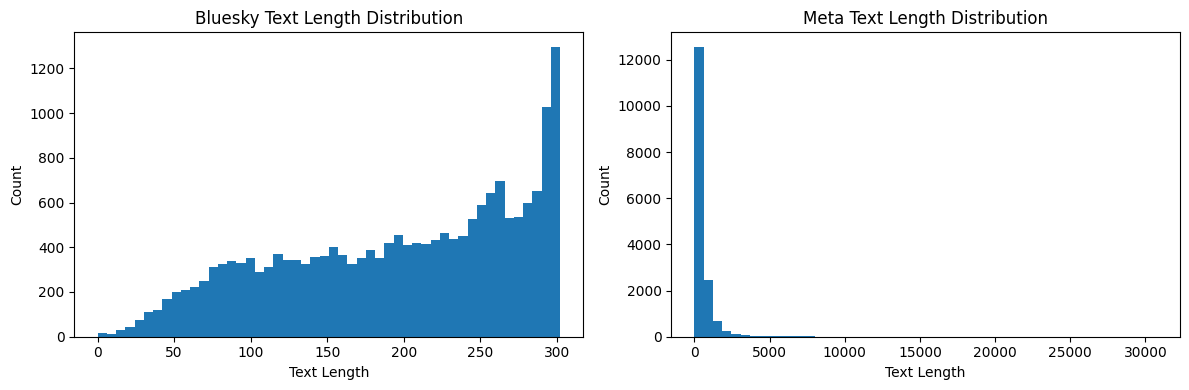

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Bluesky
plt.subplot(1,2,1)
plt.hist(bluesky_en['text_len'], bins=50)
plt.title('Bluesky Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Count')

# Meta
plt.subplot(1,2,2)
plt.hist(meta_en['text_len'], bins=50)
plt.title('Meta Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Bluesky posts are generally longer and more evenly distributed, while Meta posts are mostly very short with a few extremely long outliers.**

# report how many posts were removed

In [102]:
meta_original = len(meta)
bluesky_original = len(bluesky)

meta_cleaned = len(meta_clean)
bluesky_cleaned = len(bluesky_clean)

meta_removed = meta_original - meta_cleaned
bluesky_removed = bluesky_original - bluesky_cleaned

meta_removed_prop = meta_removed / meta_original
bluesky_removed_prop = bluesky_removed / bluesky_original

summary_table = pd.DataFrame({
    'Platform': ['Meta', 'Bluesky'],
    'Total Posts (Original)': [meta_original, bluesky_original],
    'Posts After Cleaning': [meta_cleaned, bluesky_cleaned],
    'Posts Removed': [meta_removed, bluesky_removed],
    'Removal Rate': [meta_removed_prop, bluesky_removed_prop]
})

print("Table 1. Summary of Post Counts Before and After Cleaning")
summary_table

Table 1. Summary of Post Counts Before and After Cleaning


,Platform,Total Posts (Original),Posts After Cleaning,Posts Removed,Removal Rate
0,Meta,17026,16322,704,0.041349
1,Bluesky,19182,18977,205,0.010687


#